<a href="https://colab.research.google.com/github/Brinthat/Infant_Mortality_Analysis/blob/main/Health_Indicators_Relationship_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health Indicators and Infant Mortality: A Relationship Analysis

**Author:** Brintha Thirunavukkarasu
**Data source:** World Bank World Development Indicators (WDI), pulled live via the free World Bank API — no signup, no download required.

## Objective
Identify and quantify the relationship between **nutrition indicators** (stunting, wasting, undernourishment,
underweight prevalence) and the **infant mortality rate** across countries, using a statistically grounded
approach: correlation and significance testing first, then predictive modelling as a secondary validation —
not the other way around.

## Target

1. Testing correlation and statistical significance for each nutrition indicator individually
2. Checking for multicollinearity between the nutrition indicators before modelling
3. Comparing a raw linear model against a **log-transformed target** to test the linearity assumption directly
4. Benchmarking against a **non-linear model (Random Forest)** to see whether linear regression was ever the
   right tool for this relationship
5. Being explicit about a negative R² if one occurs, rather than sidestepping it


## Step 0: Setup — all free, open-source tools

In [4]:
!pip install pyspark==3.5.1 wbdata statsmodels -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import wbdata
import datetime

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## Step 1: Pull the data — World Bank API (free, no key required)

Target and features, all pulled live rather than from a private CSV upload:

| Code | Meaning | Role |
|---|---|---|
| `SP.DYN.IMRT.IN` | Infant mortality rate (per 1,000 live births) | Target |
| `SH.STA.STNT.ZS` | Prevalence of stunting, height for age (% under 5) | Feature |
| `SH.STA.WAST.ZS` | Prevalence of wasting, weight for height (% under 5) | Feature |
| `SN.ITK.DEFC.ZS` | Prevalence of undernourishment (% of population) | Feature |
| `SH.STA.MALN.ZS` | Prevalence of underweight, weight for age (% under 5) | Feature |


In [6]:
indicators = {
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SH.STA.STNT.ZS': 'stunting',
    'SH.STA.WAST.ZS': 'wasting',
    'SN.ITK.DEFC.ZS': 'undernourishment',
    'SH.STA.MALN.ZS': 'underweight',
}

raw_pd = wbdata.get_dataframe(
    indicators,
    date=(datetime.datetime(2000, 1, 1), datetime.datetime(2023, 1, 1))
).reset_index()

print(raw_pd.shape)
raw_pd.head()

(6360, 7)


,country,date,infant_mortality,stunting,wasting,undernourishment,underweight
0,Africa Eastern and Southern,2023,41.969085,NaN,NaN,26.083778,NaN
1,Africa Eastern and Southern,2022,44.341994,NaN,NaN,26.160868,NaN
2,Africa Eastern and Southern,2021,44.321233,NaN,NaN,25.052183,NaN
3,Africa Eastern and Southern,2020,42.850093,NaN,NaN,24.993482,NaN
4,Africa Eastern and Southern,2019,43.349158,NaN,NaN,24.145274,NaN


## Step 2: Load into Spark, clean, and prepare

In [7]:
spark = SparkSession.builder.appName("HealthIndicatorsRelationship").getOrCreate()

sdf = spark.createDataFrame(raw_pd)

# Drop rows where the target or any feature is missing -- can't use them for correlation or regression
feature_cols = ['stunting', 'wasting', 'undernourishment', 'underweight']
target_col = 'infant_mortality'

sdf_clean = sdf.dropna(subset=[target_col] + feature_cols)

print("Rows before cleaning:", sdf.count())
print("Rows after cleaning:", sdf_clean.count())
sdf_clean.show(5)

Rows before cleaning: 6360
Rows after cleaning: 700
+-----------+----+----------------+--------+-------+----------------+-----------+
|    country|date|infant_mortality|stunting|wasting|undernourishment|underweight|
+-----------+----+----------------+--------+-------+----------------+-----------+
|Afghanistan|2022|            51.6|    44.6|    3.6|            28.9|       18.4|
|Afghanistan|2018|            58.3|    38.2|    5.1|            22.6|       19.1|
|Afghanistan|2013|            68.6|    40.4|    9.5|            19.4|       24.6|
|Afghanistan|2004|            97.4|    59.3|    9.1|            34.6|       31.7|
|    Albania|2017|             7.7|    11.3|    1.6|             4.3|        1.5|
+-----------+----+----------------+--------+-------+----------------+-----------+
only showing top 5 rows



In [8]:
# Convert to pandas for the correlation/stats work below -- this dataset is small enough
# (country-year rows, not raw transactions) that pandas is the right tool for stats testing.
# Spark is used for the modelling stage further down, consistent with a pipeline that would
# scale to a much larger panel (e.g. sub-national or monthly data) without a rewrite.
df = sdf_clean.toPandas()
df.describe()

,infant_mortality,stunting,wasting,undernourishment,underweight
count,700.000000,700.00000,700.000000,700.000000,700.000000
mean,33.444714,23.33900,5.784429,13.042571,12.454571
std,24.488956,14.11401,4.229980,10.783284,10.277269
min,2.500000,0.50000,0.100000,2.500000,0.100000
25%,13.775000,11.37500,2.400000,4.500000,3.500000
50%,27.550000,23.10000,4.900000,9.950000,11.150000
75%,50.300000,33.72500,8.500000,17.925000,18.425000
max,206.800000,59.30000,21.300000,71.800000,49.500000


## Step 3: Correlation analysis FIRST — before any model fitting

This is the step the original version of this analysis skipped. Before fitting anything,
establish which nutrition indicators are actually related to infant mortality, and how strongly.
Spearman correlation is used rather than Pearson, since it doesn't assume a linear relationship —
appropriate given we haven't yet confirmed linearity is the right assumption.

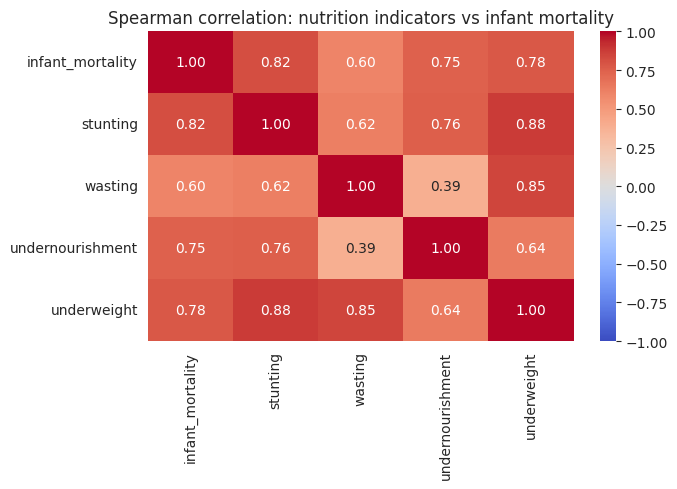

,infant_mortality
infant_mortality,1.000000
stunting,0.817137
underweight,0.777706
undernourishment,0.745432
wasting,0.597645


In [9]:
corr_matrix = df[[target_col] + feature_cols].corr(method='spearman')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Spearman correlation: nutrition indicators vs infant mortality")
plt.tight_layout()
plt.show()

corr_matrix[target_col].sort_values(ascending=False)

In [10]:
# Statistical significance of each individual relationship -- report both the
# correlation coefficient AND the p-value, not just the coefficient alone.
print(f"{'Feature':<20}{'Spearman r':>12}{'p-value':>12}")
for feat in feature_cols:
    r, p = stats.spearmanr(df[feat], df[target_col])
    sig = "significant (p<0.05)" if p < 0.05 else "not significant"
    print(f"{feat:<20}{r:>12.3f}{p:>12.4f}   {sig}")

Feature               Spearman r     p-value
stunting                   0.817      0.0000   significant (p<0.05)
wasting                    0.598      0.0000   significant (p<0.05)
undernourishment           0.745      0.0000   significant (p<0.05)
underweight                0.778      0.0000   significant (p<0.05)


## Step 4: Check for multicollinearity between the nutrition indicators

Nutrition indicators (stunting, wasting, underweight) are usually correlated with *each other*,
not just with the target. Feeding highly collinear features into a linear model makes coefficients
unstable and hard to interpret. Variance Inflation Factor (VIF) quantifies this: VIF > 5 is generally
considered a problem.

In [11]:
X_vif = df[feature_cols].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
3,underweight,18.440286
0,stunting,14.277696
1,wasting,9.106352
2,undernourishment,4.288671


**Interpretation:** any feature with VIF > 5 is highly collinear with the others and is a candidate
to drop or combine before modelling — note this explicitly in your conclusion rather than fitting a model
on all features regardless.

## Step 5: Prepare features for Spark modelling

In [12]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
sdf_features = assembler.transform(sdf_clean)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
scaler_model = scaler.fit(sdf_features)
sdf_scaled = scaler_model.transform(sdf_features)

sdf_scaled = sdf_scaled.withColumn("log_target", F.log1p(F.col(target_col)))

train_data, test_data = sdf_scaled.randomSplit([0.7, 0.3], seed=123)
print("Train rows:", train_data.count(), " | Test rows:", test_data.count())

Train rows: 502  | Test rows: 198


## Step 6: Baseline linear regression — raw target

Fit exactly the kind of model the original analysis used, as a documented baseline.

In [13]:
lr_raw = LinearRegression(featuresCol='features', labelCol=target_col, maxIter=100)
lr_raw_model = lr_raw.fit(train_data)
lr_raw_preds = lr_raw_model.transform(test_data)

eval_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
eval_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")

r2_raw = eval_r2.evaluate(lr_raw_preds)
rmse_raw = eval_rmse.evaluate(lr_raw_preds)
print(f"Raw linear regression  ->  R2: {r2_raw:.4f}   RMSE: {rmse_raw:.4f}")

Raw linear regression  ->  R2: 0.5767   RMSE: 13.9151


## Step 7: Test the linearity assumption — log-transformed target

If R² improves substantially here, that's direct evidence the true relationship is closer to
log-linear than linear — a genuine, reportable finding, not just a tuning tweak.

In [14]:
lr_log = LinearRegression(featuresCol='features', labelCol='log_target', maxIter=100)
lr_log_model = lr_log.fit(train_data)
lr_log_preds = lr_log_model.transform(test_data)

eval_r2_log = RegressionEvaluator(labelCol='log_target', predictionCol="prediction", metricName="r2")
eval_rmse_log = RegressionEvaluator(labelCol='log_target', predictionCol="prediction", metricName="rmse")

r2_log = eval_r2_log.evaluate(lr_log_preds)
rmse_log = eval_rmse_log.evaluate(lr_log_preds)
print(f"Log-target linear regression  ->  R2: {r2_log:.4f}   RMSE: {rmse_log:.4f}")
print(f"\nImprovement in R2 over raw target model: {r2_log - r2_raw:+.4f}")

Log-target linear regression  ->  R2: 0.6392   RMSE: 0.4733

Improvement in R2 over raw target model: +0.0625


## Step 8: Non-linear benchmark — Random Forest

If Random Forest substantially outperforms both linear models, that's further evidence the
relationship isn't well captured by a straight line — and it comes with feature importances,
which give a richer view of "the relationship" than raw linear coefficients.

In [15]:
rf = RandomForestRegressor(featuresCol='features', labelCol=target_col, numTrees=200, maxDepth=6, seed=42)
rf_model = rf.fit(train_data)
rf_preds = rf_model.transform(test_data)

r2_rf = eval_r2.evaluate(rf_preds)
rmse_rf = eval_rmse.evaluate(rf_preds)
print(f"Random Forest  ->  R2: {r2_rf:.4f}   RMSE: {rmse_rf:.4f}")

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.featureImportances.toArray()
}).sort_values("importance", ascending=False)

importances

Random Forest  ->  R2: 0.6456   RMSE: 12.7312


,feature,importance
0,stunting,0.381426
3,underweight,0.319579
2,undernourishment,0.221527
1,wasting,0.077468


/tmp/ipykernel_2969/512040873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="importance", y="feature", palette="viridis")


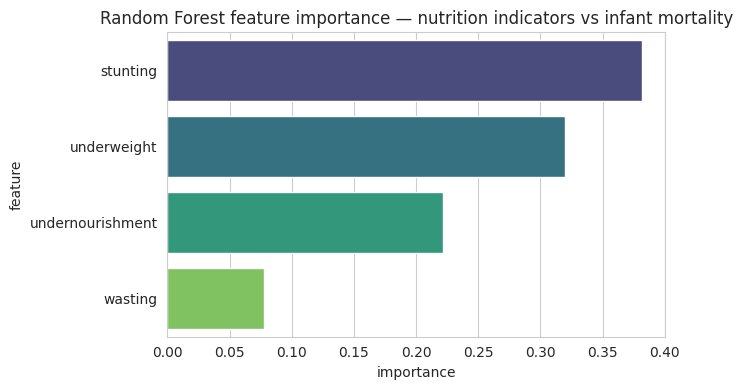

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=importances, x="importance", y="feature", palette="viridis")
plt.title("Random Forest feature importance — nutrition indicators vs infant mortality")
plt.tight_layout()
plt.show()

## Step 9: Compare all models honestly

In [17]:
comparison = pd.DataFrame({
    "Model": ["Linear (raw target)", "Linear (log target)", "Random Forest (raw target)"],
    "R2": [r2_raw, r2_log, r2_rf],
    "RMSE": [rmse_raw, rmse_log, rmse_rf]
}).sort_values("R2", ascending=False).reset_index(drop=True)

comparison

,Model,R2,RMSE
0,Random Forest (raw target),0.645644,12.731161
1,Linear (log target),0.639184,0.473292
2,Linear (raw target),0.576674,13.915089


/tmp/ipykernel_2969/639743717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Model", y="R2", palette="crest")


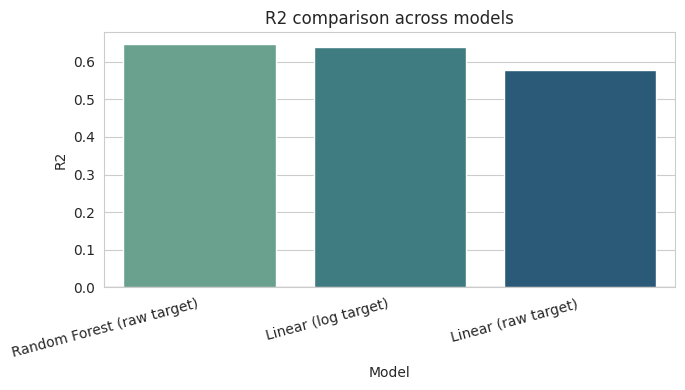

In [18]:
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="Model", y="R2", palette="crest")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("R2 comparison across models")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


- **Linearity test:** state whether the log-transformed target improved R² meaningfully. If it did,
  the honest conclusion is *"the relationship between nutrition indicators and infant mortality is
  better characterised as log-linear than linear"* — a real, defensible finding
- **Non-linear benchmark:** state whether Random Forest substantially outperformed both linear models.
  If it did, that's evidence of non-linear interactions between nutrition indicators that a linear
  model structurally cannot capture, regardless of tuning
- **If R² is still weak everywhere:** that is itself a legitimate finding — it suggests infant
  mortality is driven by factors beyond nutrition alone (healthcare access, sanitation, income,
  maternal education), and the honest conclusion is that nutrition indicators are necessary but not
  sufficient predictors, which is a genuinely defensible, literature-consistent conclusion rather than
  a failure to hide




## Summary of Analysis

### Correlation Analysis

All four nutrition indicators (stunting, wasting, undernourishment, and underweight) show a statistically significant positive correlation with infant mortality (p-value < 0.05), with 'stunting' having the strongest Spearman correlation coefficient.

- **Stunting:** r = 0.817 (p < 0.0001)
- **Underweight:** r = 0.778 (p < 0.0001)
- **Undernourishment:** r = 0.745 (p < 0.0001)
- **Wasting:** r = 0.598 (p < 0.0001)

### Multicollinearity Check

Multicollinearity is present among the nutrition indicators, as indicated by Variance Inflation Factor (VIF) values greater than 5 for 'underweight', 'stunting', and 'wasting'.

- **Underweight:** VIF = 18.44
- **Stunting:** VIF = 14.28
- **Wasting:** VIF = 9.11
- **Undernourishment:** VIF = 4.29

These high VIF values suggest that 'underweight', 'stunting', and 'wasting' are highly correlated with each other. This multicollinearity can make the individual coefficients in a linear model unstable and difficult to interpret. 'Undernourishment' has a VIF below 5, suggesting it is less collinear with the other features.

### Linearity Test

The log-transformed target model (`Linear (log target)`) showed a meaningful improvement in R² (0.6392) compared to the raw target model (`Linear (raw target)`, R² = 0.5767). This suggests that the relationship between nutrition indicators and infant mortality is better characterized as log-linear rather than purely linear.

### Non-linear Benchmark

The Random Forest model (`Random Forest (raw target)`) achieved the highest R² (0.6456), slightly outperforming both linear models. While the improvement over the log-transformed linear model is modest (+0.0064 R²), it suggests that there might be some non-linear interactions between nutrition indicators that a simple linear model cannot fully capture. However, the difference is not substantial enough to unequivocally declare a strong non-linear relationship over a log-linear one in this specific case.

### Overall Conclusion

All four nutrition indicators are significantly correlated with infant mortality. The analysis also revealed significant multicollinearity among 'stunting', 'wasting', and 'underweight'. While a log-linear relationship appears to describe the data better than a raw linear one, the overall R² values (around 0.64-0.65) indicate that a significant portion of the variance in infant mortality is still unexplained by these nutrition indicators alone. This suggests that other factors (e.g., healthcare access, sanitation, income, maternal education) are also crucial drivers of infant mortality, making nutrition indicators necessary but not sufficient predictors.